# 05b - latent CVs and one-step rollout comparison

Train two-dimensional latent autoencoders and one-step delta-z propagators. The shared final runs use 20 training networks for de Pablo and 30 for Reid. The notebook focuses on whether the two latent coordinates carry related but non-identical information and whether their autoregressive rollout preserves Poisson ratio.

In [36]:
%matplotlib inline

import os
import sys
from pathlib import Path

os.environ.setdefault("MPLBACKEND", "module://matplotlib_inline.backend_inline")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src" / "lss").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.colors import Normalize
from graph_utils import calc_p_ratio_rollout_sides, directional_side_indices_from_box

from lss.latent.analysis import framewise_latent_descriptor_sweep
from lss.latent.capacity import experiment_config_fingerprint, final_05_2d_propagator_config
from lss.latent.experiment import run_latent_experiment, seed_everything
from lss.latent.simulation import pearson_r, r2_score
from lss.latent.training import decode_latent_to_graph, encode_frame_latent
from lss.plotting import PAPER_COLORS, apply_editorial_style, style_axes
from lss.utils import resolve_device

apply_editorial_style()
DEVICE = resolve_device("auto")
DEVICE


'cuda'

## Settings

Use `FORCE_TRAIN=True` only when you intentionally want to retrain and overwrite the shared final models.

In [37]:
BASE_SEED = 20260710
SEED_OFFSETS = [0, 1000, 2000]
SEED_LABELS = [f'seed {index+1}' for index in range(len(SEED_OFFSETS))]
FORCE_TRAIN = False

FRAME_STRIDE = 4
MAX_ANALYSIS_FRAMES_PER_SIM = 100
ROLLOUT_STEPS_GRID = [10, 20, 50, 100, 150, 199]
ROLLOUT_EVAL_MAX_SIMS_PER_SPLIT = 30

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "results" / "05b_20net_latent_rollout"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CASES = {
    "depablo_low_temp": {
        "dataset_name": "depablo_low_temp",
        "label": "dePablo",
        "path": PROJECT_ROOT / "data" / "depablo-near-zero-temp.pt",
    },
    "reid": {
        "dataset_name": "reid",
        "label": "Reid",
        "path": PROJECT_ROOT / "data" / "reid_200_frames.pt",
    },
    "depablo_mixed_temp": {
        "dataset_name": "depablo_mixed_temp",
        "label": "dePablo mixed-T",
        "path": PROJECT_ROOT / "data" / "depablo-10k-mix-temp.pt",
    },
}

for key, spec in CASES.items():
    assert spec["path"].exists(), f"Missing dataset for {key}: {spec['path']}"

DATASET_STYLE = {
    "depablo_low_temp": {"color": PAPER_COLORS["blue"], "marker": "o", "short": "dePablo"},
    "reid": {"color": PAPER_COLORS["red"], "marker": "s", "short": "Reid"},
    "depablo_mixed_temp": {"color": PAPER_COLORS["green"], "marker": "^", "short": "dePablo mixed-T"},
}


In [38]:
def build_case_config(case_key: str, case_spec: dict, *, seed: int) -> tuple[dict, dict]:
    split_seed = BASE_SEED + 101 * (list(CASES).index(case_key) + 1)
    shared_dir = OUTPUT_DIR / 'capacity_sweep' / case_key
    shared_dir.mkdir(parents=True, exist_ok=True)
    ae_config = {
        "latent_dim": 2,
        "latent_tokens": 32,
        "hidden_size": 96,
        "model": "attention",
        "edge_feature_dim": 12,
        "target_mode": "normalized_delta",
        "node_feature_mode": "normalized_delta",
        "max_train_frames_per_sim": 101,
        "max_epochs": 80,
        "patience": 8,
        "lr": 5e-5,
        "weight_decay": 1e-5,
    }
    propagator_config = {
        "max_train_transitions_per_sim": 100,
        "max_epochs": 80,
        "patience": 8,
        "lr": 5e-5,
        "weight_decay": 1e-5,
        "use_static_context": True,
        "context_dim": 16,
        "step_stride": 1,
        "initial_velocity": "zero",
        "objective": "one_step",
        "model": "delta_mlp",
        "loss": "delta",
        "standardize_latent": False,
        "rollout_eval_every_epoch": True,
        "rollout_eval_horizon": 100,
        "rollout_eval_max_sims": None,
    }
    experiment_config = {
        "ae_config": ae_config,
        "propagator_config": propagator_config,
        "dataset_name": case_spec["dataset_name"],
        "split_seed": split_seed,
        "split_stratify_temperature": False,
        "min_train_p_ratio": None,
        "device": str(DEVICE),
        "pos_dim": 2,
        "batch_graphs": 4,
        "frame_skip": 1,
        "train_frame_start_order": 0,
        "early_stop_min_delta": 1e-5,
        "rollout_steps_grid": ROLLOUT_STEPS_GRID,
        "rollout_eval_max_sims_per_split": ROLLOUT_EVAL_MAX_SIMS_PER_SPLIT,
        "should_rollout": True,
        "should_train_propagator": True,
        "force_train": bool(FORCE_TRAIN),
        "cache_path": None,
        "model_seed": seed,
        "repeat_idx": 1,
    }
    cache_identity = {**experiment_config, 'source_path': str(case_spec['path']), 'train_count': 20, 'val_count': 20}
    cache_tag = experiment_config_fingerprint(cache_identity)
    experiment_config['cache_path'] = str(shared_dir / f'rollout_attention_cv2_train20_{cache_tag}.pt')
    source_spec = {
        "dataset_name": case_spec["dataset_name"],
        "source_name": case_spec["label"],
        "label": f"{case_spec['label']} CV2, train=20",
        "path": str(case_spec["path"]),
        "dataset_mixture": [
            {
                "name": case_spec["dataset_name"],
                "label": case_spec["label"],
                "path": str(case_spec["path"]),
                "train_count": 20,
                "val_count": 20,
            }
        ],
    }
    return experiment_config, source_spec


def run_or_load_case(case_key: str, case_spec: dict, *, repeat_index: int = 0) -> dict:
    split_seed = BASE_SEED + 101 * (list(CASES).index(case_key) + 1)
    seed = split_seed + SEED_OFFSETS[repeat_index]
    experiment_config, source_spec = build_case_config(case_key, case_spec, seed=seed)
    seed_everything(seed)
    result = run_latent_experiment(source_spec, experiment_config, device=DEVICE)
    result["case_key"] = case_key
    result["case_label"] = case_spec["label"]
    result["case_cfg"] = experiment_config
    result["repeat_index"] = repeat_index
    result["model_seed"] = seed
    return result


## Train Or Load 20-Network Models

In [39]:
seeded_results = {
    (key, repeat_index): run_or_load_case(key, spec, repeat_index=repeat_index)
    for key, spec in CASES.items() for repeat_index in range(len(SEED_OFFSETS))
}
# Latent-coordinate analyses use the first complete run; rollout uncertainty uses all runs.
results = {key: seeded_results[(key, 0)] for key in CASES}

split_tables = []
for (key, repeat_index), result in seeded_results.items():
    table = result["split_info"].copy()
    table.insert(0, "case", key)
    table.insert(1, "repeat_index", repeat_index)
    table.insert(2, "model_seed", result['model_seed'])
    split_tables.append(table)
split_info = pd.concat(split_tables, ignore_index=True)
split_info.to_csv(OUTPUT_DIR / "split_info.csv", index=False)
display(split_info)



=== dePablo CV2, train=20 ===
          source                                                                path  total  train  reserved_train_pool  val  test
depablo_low_temp /home/alexz/Documents/course_project/data/depablo-near-zero-temp.pt    200     20                   20   20   160
autoencoder
ae 0001 train=0.821177 val=0.424743 stale=0
ae 0002 train=0.553071 val=0.370443 stale=0
ae 0003 train=0.456039 val=0.329751 stale=0
ae 0004 train=0.401341 val=0.316491 stale=0
ae 0005 train=0.308247 val=0.225108 stale=0
ae 0006 train=0.193375 val=0.131473 stale=0
ae 0007 train=0.116362 val=0.0906755 stale=0
ae 0008 train=0.0949291 val=0.0842012 stale=0
ae 0009 train=0.0901322 val=0.0799056 stale=0
ae 0010 train=0.0876517 val=0.0817293 stale=1
ae 0011 train=0.0861271 val=0.0774239 stale=0
ae 0013 train=0.0829584 val=0.0761405 stale=0
ae 0015 train=0.0815452 val=0.0761216 stale=0
ae 0016 train=0.0806995 val=0.0752934 stale=0
ae 0020 train=0.0780329 val=0.0789302 stale=4
ae early stop at e

,case,repeat_index,model_seed,source,path,total,train,reserved_train_pool,val,test
0,depablo_low_temp,0,20260811,depablo_low_temp,/home/alexz/Documents/course_project/data/depa...,200,20,20,20,160
1,depablo_low_temp,1,20261811,depablo_low_temp,/home/alexz/Documents/course_project/data/depa...,200,20,20,20,160
2,depablo_low_temp,2,20262811,depablo_low_temp,/home/alexz/Documents/course_project/data/depa...,200,20,20,20,160
3,reid,0,20260912,reid,/home/alexz/Documents/course_project/data/reid...,102,30,30,20,52
4,reid,1,20261912,reid,/home/alexz/Documents/course_project/data/reid...,102,30,30,20,52
5,reid,2,20262912,reid,/home/alexz/Documents/course_project/data/reid...,102,30,30,20,52
6,depablo_mixed_temp,0,20261013,depablo_mixed_temp,/home/alexz/Documents/course_project/data/depa...,300,20,20,20,260
7,depablo_mixed_temp,1,20262013,depablo_mixed_temp,/home/alexz/Documents/course_project/data/depa...,300,20,20,20,260
8,depablo_mixed_temp,2,20263013,depablo_mixed_temp,/home/alexz/Documents/course_project/data/depa...,300,20,20,20,260


## Latent Descriptor Tables

In [40]:
def trajectory_descriptor_table(frame_df: pd.DataFrame, *, case_key: str, case_label: str) -> pd.DataFrame:
    z_cols = sorted(
        [col for col in frame_df.columns if col.startswith("z") and col[1:].isdigit()],
        key=lambda col: int(col[1:]),
    )
    rows = []
    for (split, sim_idx), group in frame_df.sort_values(["split", "sim_idx", "frame_idx"]).groupby(["split", "sim_idx"]):
        first = group.iloc[0]
        last = group.iloc[-1]
        time = group["frame_idx"].to_numpy(float)
        row = {
            "case": case_key,
            "case_label": case_label,
            "split": split,
            "sim_idx": int(sim_idx),
            "source": first.get("source", case_label),
            "temperature": float(first.get("temperature", np.nan)),
            "n_encoded_frames": int(len(group)),
            "first_frame": int(first["frame_idx"]),
            "last_frame": int(last["frame_idx"]),
            "final_p_ratio": float(first["side_final_trajectory_p_ratio"]),
        }
        for z_col in z_cols:
            values = group[z_col].to_numpy(float)
            slope, intercept = np.polyfit(time, values, deg=1)
            residual = values - (slope * time + intercept)
            row[f"{z_col}_initial"] = float(values[0])
            row[f"{z_col}_final"] = float(values[-1])
            row[f"{z_col}_slope"] = float(slope)
            row[f"{z_col}_std"] = float(np.nanstd(values))
            row[f"{z_col}_detrended_std"] = float(np.nanstd(residual))
        rows.append(row)
    return pd.DataFrame(rows)


frame_tables = []
descriptor_tables = []
score_tables = []
rollout_tables = []

for key, result in results.items():
    frame_df, score_df, prediction_df, weight_df = framewise_latent_descriptor_sweep(
        result,
        device=DEVICE,
        frame_stride=FRAME_STRIDE,
        max_frames_per_sim=MAX_ANALYSIS_FRAMES_PER_SIM,
    )
    frame_df.insert(0, "case", key)
    frame_df.insert(1, "case_label", result["case_label"])
    score_df.insert(0, "case", key)
    score_df.insert(1, "case_label", result["case_label"])
    descriptor_df_case = trajectory_descriptor_table(frame_df, case_key=key, case_label=result["case_label"])

    case_dir = OUTPUT_DIR / key
    frame_df.to_csv(case_dir / "framewise_latent_table.csv", index=False)
    descriptor_df_case.to_csv(case_dir / "trajectory_latent_descriptors.csv", index=False)
    score_df.to_csv(case_dir / "framewise_readout_scores.csv", index=False)
    frame_tables.append(frame_df)
    descriptor_tables.append(descriptor_df_case)
    score_tables.append(score_df)

for (key, repeat_index), result in seeded_results.items():
    for measurement, stats_key in [('AE ceiling', 'ae_reconstruction_stats'), ('Latent propagator', 'rollout_stats')]:
        stats = result[stats_key].copy()
        stats.insert(0, 'case', key); stats.insert(1, 'case_label', result['case_label'])
        stats.insert(2, 'repeat_index', repeat_index); stats.insert(3, 'model_seed', result['model_seed'])
        stats.insert(4, 'measurement', measurement)
        rollout_tables.append(stats)

frame_df = pd.concat(frame_tables, ignore_index=True)
descriptor_df = pd.concat(descriptor_tables, ignore_index=True)
score_df = pd.concat(score_tables, ignore_index=True)
seeded_rollout_comparison = pd.concat(rollout_tables, ignore_index=True)
rollout_stats_df = seeded_rollout_comparison[seeded_rollout_comparison.measurement.eq('Latent propagator')].copy()

frame_df.to_csv(OUTPUT_DIR / "all_framewise_latent_table.csv", index=False)
descriptor_df.to_csv(OUTPUT_DIR / "all_trajectory_latent_descriptors.csv", index=False)
score_df.to_csv(OUTPUT_DIR / "all_framewise_readout_scores.csv", index=False)
rollout_stats_df.to_csv(OUTPUT_DIR / "all_latent_rollout_stats.csv", index=False)
seeded_rollout_comparison.to_csv(OUTPUT_DIR / 'three_seed_ae_ceiling_vs_rollout_reid_small_ae200_v1.csv', index=False)
three_seed_rollout_summary = seeded_rollout_comparison.groupby(['case','case_label','measurement','split','rollout_steps']).p_ratio_r2.agg(mean_r2='mean', std_r2='std', min_r2='min', max_r2='max', n_seeds='count').reset_index()
three_seed_rollout_summary.to_csv(OUTPUT_DIR / 'three_seed_rollout_summary_reid_small_ae200_v1.csv', index=False)

display(descriptor_df.head())


,case,case_label,split,sim_idx,source,temperature,n_encoded_frames,first_frame,last_frame,final_p_ratio,z0_initial,z0_final,z0_slope,z0_std,z0_detrended_std,z1_initial,z1_final,z1_slope,z1_std,z1_detrended_std
0,depablo_low_temp,dePablo,test,0,depablo_low_temp,1.000000e-07,51,0,199,0.364319,-0.607175,3.520586,0.021381,1.264678,0.128036,1.135592,-8.632400,-0.050166,2.952827,0.068959
1,depablo_low_temp,dePablo,test,1,depablo_low_temp,1.000000e-07,51,0,199,-0.421309,-2.385383,-2.350904,0.000460,0.187438,0.185477,0.635037,-8.477173,-0.047101,2.772335,0.060362
2,depablo_low_temp,dePablo,test,2,depablo_low_temp,1.000000e-07,51,0,199,-0.247980,-2.194155,-1.627560,0.004185,0.260592,0.085257,1.400948,-9.715103,-0.056260,3.321266,0.265327
3,depablo_low_temp,dePablo,test,3,depablo_low_temp,1.000000e-07,51,0,199,-0.258473,-1.557729,-1.583624,-0.000370,0.088849,0.086147,0.296739,-9.661278,-0.050587,2.978445,0.098066
4,depablo_low_temp,dePablo,test,4,depablo_low_temp,1.000000e-07,51,0,199,0.336450,-0.805955,4.254527,0.026869,1.589357,0.161721,1.186111,-9.960992,-0.057259,3.378217,0.243292


## P-Ratio Readouts From Latent Descriptors

In [41]:
def fit_predict_linear(train_df: pd.DataFrame, test_df: pd.DataFrame, feature_cols: list[str], target_col: str, ridge: float = 1e-6) -> dict:
    train = train_df[feature_cols + [target_col]].replace([np.inf, -np.inf], np.nan).dropna()
    test = test_df[feature_cols + [target_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(feature_cols) == 0:
        raise ValueError("No feature columns were supplied for the readout.")
    if len(train) < 3 or len(test) < 3:
        raise ValueError(f"Need at least 3 train and 3 test rows for {feature_cols}; got train={len(train)}, test={len(test)}.")
    X_train = train[feature_cols].to_numpy(float)
    y_train = train[target_col].to_numpy(float)
    x_mean = X_train.mean(axis=0, keepdims=True)
    x_std = X_train.std(axis=0, keepdims=True) + 1e-12
    Xz_train = (X_train - x_mean) / x_std
    design = np.column_stack([np.ones(len(train)), Xz_train])
    penalty = np.eye(design.shape[1])
    penalty[0, 0] = 0.0
    coef = np.linalg.solve(design.T @ design + float(ridge) * penalty, design.T @ y_train)
    Xz_test = (test[feature_cols].to_numpy(float) - x_mean) / x_std
    pred = np.column_stack([np.ones(len(test)), Xz_test]) @ coef
    return {
        "r2": r2_score(test[target_col], pred),
        "pearson_r": pearson_r(test[target_col], pred),
        "n_val": int(len(train)),
        "n_test": int(len(test)),
        "n_features": int(len(feature_cols)),
    }

readout_rows = []
for case_key, group in descriptor_df.groupby("case"):
    z_initial = sorted([col for col in group.columns if col.startswith("z") and col.endswith("_initial")], key=lambda col: int(col[1:].split("_")[0]))
    z_slope = sorted([col for col in group.columns if col.startswith("z") and col.endswith("_slope")], key=lambda col: int(col[1:].split("_")[0]))
    feature_sets = {
        "Initial latent": z_initial,
        "Latent slope": z_slope,
        "Initial + slope": z_initial + z_slope,
    }
    val = group[group["split"].eq("val")]
    test = group[group["split"].eq("test")]
    for label, cols in feature_sets.items():
        metrics = fit_predict_linear(val, test, cols, "final_p_ratio")
        readout_rows.append({"case": case_key, "case_label": group["case_label"].iloc[0], "feature_set": label, **metrics})
    for col in z_initial + z_slope:
        metrics = fit_predict_linear(val, test, [col], "final_p_ratio")
        readout_rows.append({"case": case_key, "case_label": group["case_label"].iloc[0], "feature_set": col, **metrics})

readout_summary = pd.DataFrame(readout_rows).sort_values(["case", "r2"], ascending=[True, False])
readout_summary.to_csv(OUTPUT_DIR / "p_ratio_readout_summary.csv", index=False)
display(readout_summary[["case_label", "feature_set", "r2", "pearson_r", "n_val", "n_test", "n_features"]].round(3))


,case_label,feature_set,r2,pearson_r,n_val,n_test,n_features
2,dePablo,Initial + slope,0.954,0.978,20,160,4
0,dePablo,Initial latent,0.907,0.960,20,160,2
3,dePablo,z0_initial,0.865,0.936,20,160,1
5,dePablo,z0_slope,0.843,0.926,20,160,1
1,dePablo,Latent slope,0.842,0.925,20,160,2
4,dePablo,z1_initial,0.448,0.702,20,160,1
6,dePablo,z1_slope,-0.068,-0.012,20,160,1
8,dePablo mixed-T,Latent slope,0.960,0.982,20,260,2
9,dePablo mixed-T,Initial + slope,0.955,0.982,20,260,4
13,dePablo mixed-T,z1_slope,0.884,0.952,20,260,1


Network-level latent descriptors versus final p-ratio; rows are datasets and columns are descriptors.


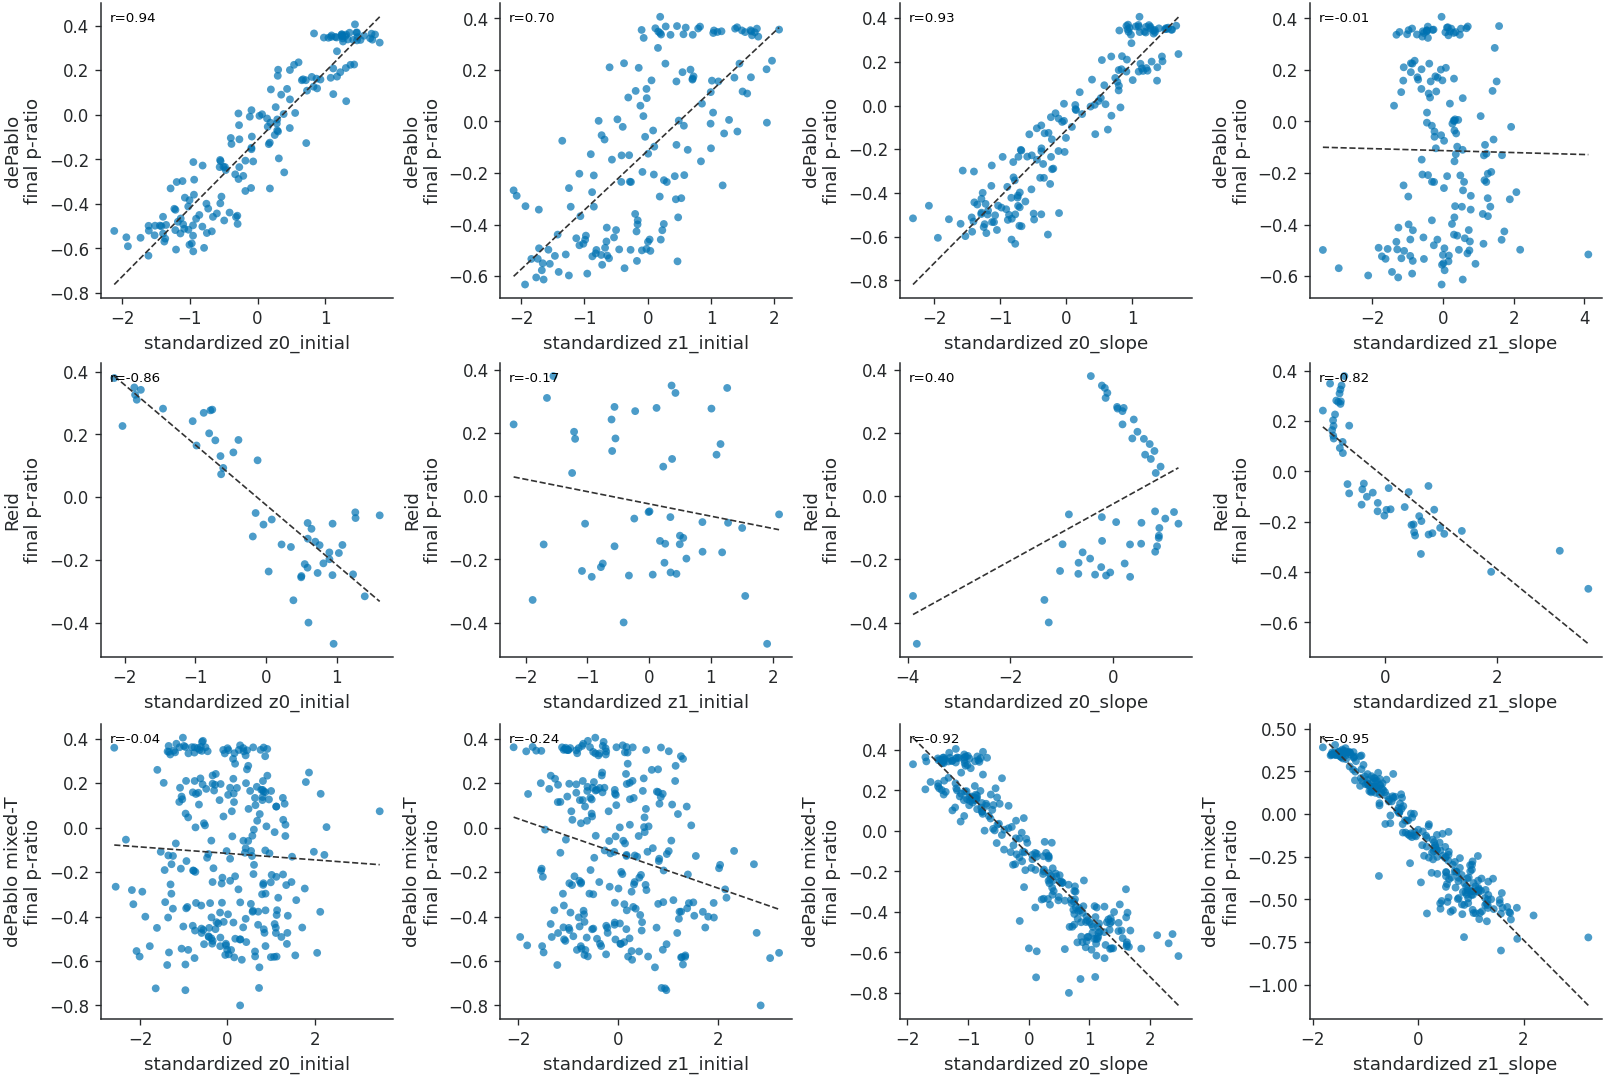

,case,case_label,descriptor,target,pearson_r,n_networks
0,depablo_low_temp,dePablo,z0_initial,final_p_ratio,0.936,160
1,depablo_low_temp,dePablo,z1_initial,final_p_ratio,0.702,160
2,depablo_low_temp,dePablo,z0_slope,final_p_ratio,0.926,160
3,depablo_low_temp,dePablo,z1_slope,final_p_ratio,-0.012,160
4,reid,Reid,z0_initial,final_p_ratio,-0.862,52
5,reid,Reid,z1_initial,final_p_ratio,-0.175,52
6,reid,Reid,z0_slope,final_p_ratio,0.405,52
7,reid,Reid,z1_slope,final_p_ratio,-0.820,52
8,depablo_mixed_temp,dePablo mixed-T,z0_initial,final_p_ratio,-0.044,260
9,depablo_mixed_temp,dePablo mixed-T,z1_initial,final_p_ratio,-0.238,260


In [42]:
# One visible dot per held-out network; no coordinate selection or dataset pooling.
import importlib
import lss.latent.analysis as latent_analysis
latent_analysis = importlib.reload(latent_analysis)
plot_network_descriptor_scatters = latent_analysis.plot_network_descriptor_scatters
case_labels = {key: value["short"] for key, value in DATASET_STYLE.items()}
fig, network_scatter_correlations = plot_network_descriptor_scatters(
    descriptor_df, case_order=list(CASES), case_labels=case_labels, target_column="final_p_ratio",
)
network_scatter_correlations.to_csv(OUTPUT_DIR/"network_descriptor_scatter_correlations.csv", index=False)
fig.savefig(OUTPUT_DIR/"network_descriptor_vs_final_pratio.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_DIR/"network_descriptor_vs_final_pratio.pdf", bbox_inches="tight")
plt.show()
display(network_scatter_correlations.round(3))


## What the latent coordinates encode: network descriptors versus trajectory dynamics

Network-level correlations use exactly one observation per held-out network: each latent coordinate at the initial frame or its fitted trajectory slope, correlated with final p-ratio or temperature. Dynamic correlations are computed separately across frames inside every trajectory and only then summarized across networks. Frames from different networks are never pooled into one correlation.

dePablo: one value per network


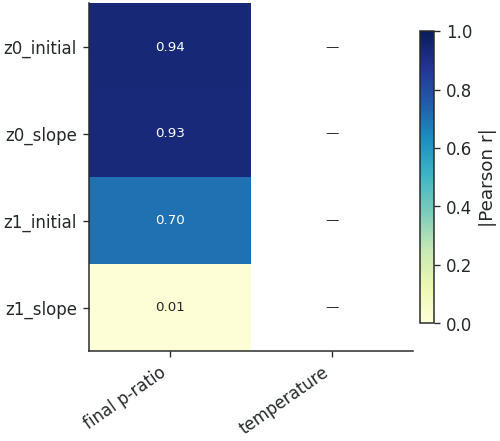

dePablo: mean within-trajectory correlation


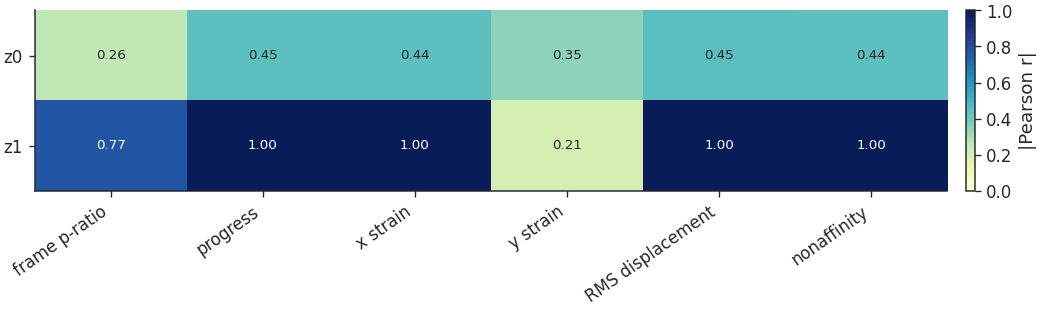

Reid: one value per network


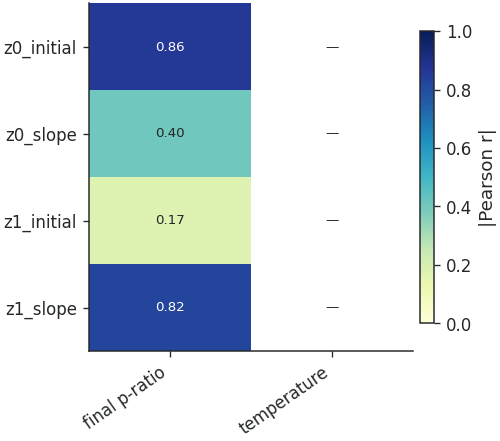

Reid: mean within-trajectory correlation


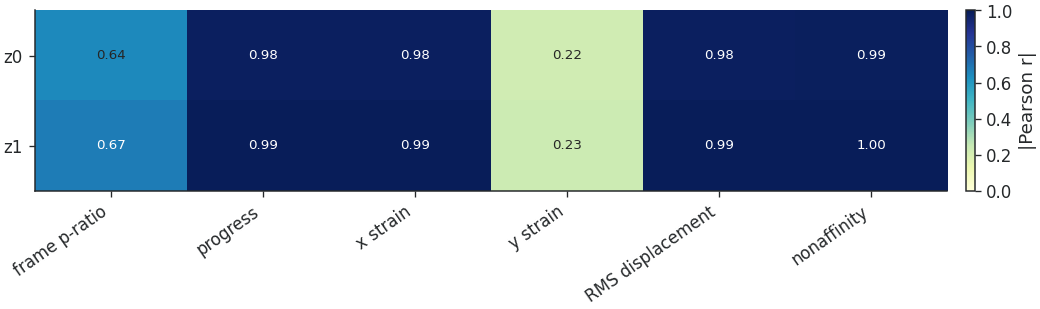

dePablo mixed-T: one value per network


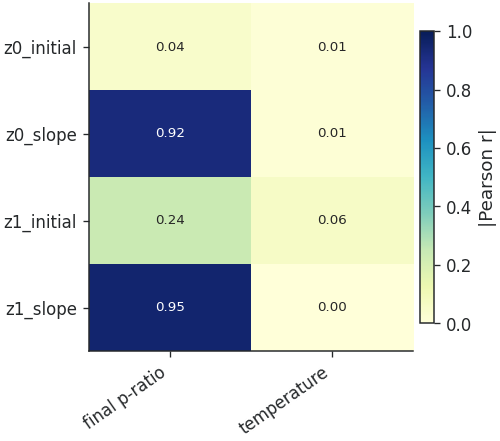

dePablo mixed-T: mean within-trajectory correlation


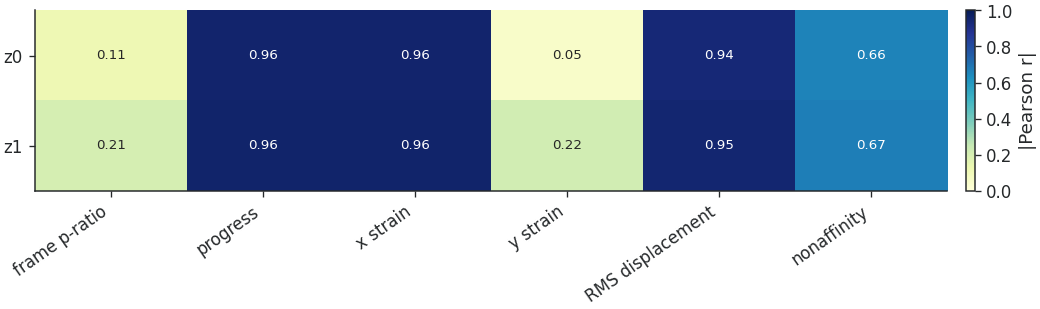

,case,case_label,descriptor,metric,metric_column,pearson_r,n_networks
0,depablo_low_temp,dePablo,z0_initial,final p-ratio,final_p_ratio,0.936,160
1,depablo_low_temp,dePablo,z0_initial,temperature,temperature,NaN,160
2,depablo_low_temp,dePablo,z1_initial,final p-ratio,final_p_ratio,0.702,160
3,depablo_low_temp,dePablo,z1_initial,temperature,temperature,NaN,160
4,depablo_low_temp,dePablo,z0_slope,final p-ratio,final_p_ratio,0.926,160
5,depablo_low_temp,dePablo,z0_slope,temperature,temperature,NaN,160
6,depablo_low_temp,dePablo,z1_slope,final p-ratio,final_p_ratio,-0.012,160
7,depablo_low_temp,dePablo,z1_slope,temperature,temperature,NaN,160
8,reid,Reid,z0_initial,final p-ratio,final_p_ratio,-0.862,52
9,reid,Reid,z0_initial,temperature,temperature,NaN,52


,case,case_label,coordinate,metric,metric_column,mean_r,median_r,std_r,n_trajectories
0,depablo_low_temp,dePablo,z0,RMS displacement,rms_disp,0.446,0.965,0.775,160
1,depablo_low_temp,dePablo,z0,frame p-ratio,side_cumulative_p_ratio,-0.258,-0.652,0.737,160
2,depablo_low_temp,dePablo,z0,nonaffinity,nonaffine_rms,0.445,0.960,0.773,160
3,depablo_low_temp,dePablo,z0,progress,frame_progress,0.445,0.965,0.775,160
4,depablo_low_temp,dePablo,z0,x strain,side_strain_x,-0.445,-0.965,0.775,160
5,depablo_low_temp,dePablo,z0,y strain,side_strain_y,0.348,0.937,0.806,160
6,depablo_low_temp,dePablo,z1,RMS displacement,rms_disp,-0.998,-0.999,0.002,160
7,depablo_low_temp,dePablo,z1,frame p-ratio,side_cumulative_p_ratio,0.772,0.873,0.348,160
8,depablo_low_temp,dePablo,z1,nonaffinity,nonaffine_rms,-0.998,-0.999,0.003,160
9,depablo_low_temp,dePablo,z1,progress,frame_progress,-0.998,-0.999,0.002,160


In [43]:
# Two estimands: one point per network, and correlations computed separately per trajectory.
import importlib
import lss.latent.analysis as latent_analysis
latent_analysis = importlib.reload(latent_analysis)
network_level_latent_correlations = latent_analysis.network_level_latent_correlations
per_trajectory_latent_correlations = latent_analysis.per_trajectory_latent_correlations
plot_correlation_heatmap = latent_analysis.plot_correlation_heatmap
network_metrics = {'final p-ratio': 'final_p_ratio', 'temperature': 'temperature'}
dynamic_metrics = {
    'frame p-ratio': 'side_cumulative_p_ratio',
    'progress': 'frame_progress', 'x strain': 'side_strain_x', 'y strain': 'side_strain_y',
    'RMS displacement': 'rms_disp', 'nonaffinity': 'nonaffine_rms',
}
network_parts, trajectory_parts, trajectory_summary_parts = [], [], []
for case_key, descriptor_group in descriptor_df.query("split == 'test'").groupby('case', sort=False):
    label = descriptor_group.case_label.iloc[0]
    network_table = network_level_latent_correlations(descriptor_group, metric_columns=network_metrics)
    network_table.insert(0, 'case', case_key); network_table.insert(1, 'case_label', label)
    network_parts.append(network_table)
    fig = plot_correlation_heatmap(network_table, row='descriptor', column='metric', value='pearson_r',
        column_order=list(network_metrics), title=f'{label}: one value per network')
    fig.savefig(OUTPUT_DIR/f'network_level_latent_correlations_{case_key}.png', dpi=300, bbox_inches='tight')
    fig.savefig(OUTPUT_DIR/f'network_level_latent_correlations_{case_key}.pdf', bbox_inches='tight')
    plt.show()
    frame_group = frame_df.query("split == 'test' and case == @case_key")
    per_trajectory, trajectory_summary = per_trajectory_latent_correlations(frame_group, metric_columns=dynamic_metrics)
    per_trajectory.insert(0, 'case', case_key); per_trajectory.insert(1, 'case_label', label)
    trajectory_summary.insert(0, 'case', case_key); trajectory_summary.insert(1, 'case_label', label)
    trajectory_parts.append(per_trajectory); trajectory_summary_parts.append(trajectory_summary)
    fig = plot_correlation_heatmap(trajectory_summary, row='coordinate', column='metric', value='mean_r',
        column_order=list(dynamic_metrics), title=f'{label}: mean within-trajectory correlation')
    fig.savefig(OUTPUT_DIR/f'within_trajectory_latent_correlations_{case_key}.png', dpi=300, bbox_inches='tight')
    fig.savefig(OUTPUT_DIR/f'within_trajectory_latent_correlations_{case_key}.pdf', bbox_inches='tight')
    plt.show()
network_correlations = pd.concat(network_parts, ignore_index=True)
trajectory_correlations = pd.concat(trajectory_parts, ignore_index=True)
trajectory_correlation_summary = pd.concat(trajectory_summary_parts, ignore_index=True)
network_correlations.to_csv(OUTPUT_DIR/'network_level_latent_correlations.csv', index=False)
trajectory_correlations.to_csv(OUTPUT_DIR/'within_trajectory_latent_correlations_per_network.csv', index=False)
trajectory_correlation_summary.to_csv(OUTPUT_DIR/'within_trajectory_latent_correlations_summary.csv', index=False)
display(network_correlations.round(3)); display(trajectory_correlation_summary.round(3))


## Effective latent dimensionality

Coordinate correlation is basis-dependent. These diagnostics instead examine the latent plane as a whole: its singular spectrum, effective rank, held-out multivariate probes, and decoded interventions along its principal directions.

/tmp/ipykernel_2495963/4098311476.py:61: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  x_fit_z = np.row_stack([x_train_z, x_val_z]); y_fit_z = np.row_stack([y_train_z, y_val_z])
/tmp/ipykernel_2495963/4098311476.py:61: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  x_fit_z = np.row_stack([x_train_z, x_val_z]); y_fit_z = np.row_stack([y_train_z, y_val_z])
/tmp/ipykernel_2495963/4098311476.py:61: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  x_fit_z = np.row_stack([x_train_z, x_val_z]); y_fit_z = np.row_stack([y_train_z, y_val_z])


,case,case_label,pc1_variance_fraction,pc2_variance_fraction,singular_value_ratio_s2_over_s1,effective_rank,participation_ratio,n_frames
0,depablo_low_temp,dePablo,0.662,0.338,0.714,1.895,1.809,8160
1,reid,Reid,0.917,0.083,0.302,1.332,1.180,2652
2,depablo_mixed_temp,dePablo mixed-T,0.642,0.358,0.746,1.920,1.850,13260


,case,case_label,representation,target,test_r2,selected_angle_degrees
0,depablo_low_temp,dePablo,best shared 1D projection,frame p-ratio,0.549,51.713
1,depablo_low_temp,dePablo,best shared 1D projection,x strain,0.395,51.713
2,depablo_low_temp,dePablo,best shared 1D projection,y strain,0.641,51.713
3,depablo_low_temp,dePablo,best shared 1D projection,RMS displacement,0.507,51.713
4,depablo_low_temp,dePablo,best shared 1D projection,nonaffinity,0.895,51.713
5,depablo_low_temp,dePablo,best shared 1D projection,mean across targets,0.597,51.713
6,depablo_low_temp,dePablo,full 2D latent plane,frame p-ratio,0.890,51.713
7,depablo_low_temp,dePablo,full 2D latent plane,x strain,0.960,51.713
8,depablo_low_temp,dePablo,full 2D latent plane,y strain,0.909,51.713
9,depablo_low_temp,dePablo,full 2D latent plane,RMS displacement,0.858,51.713


Held-out latent-plane spectrum and effective dimensionality.


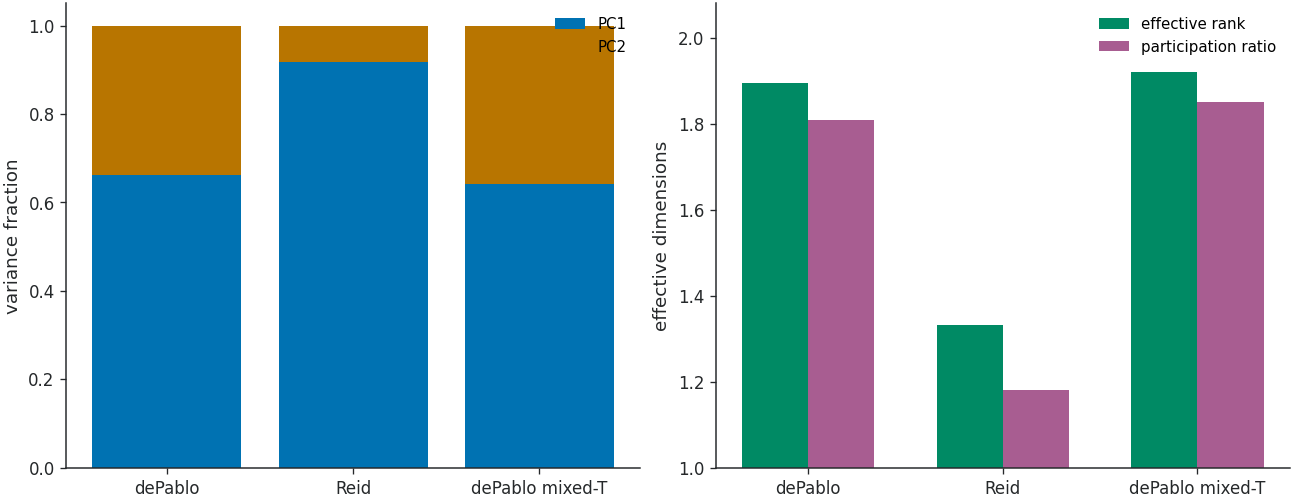

Held-out multivariate physical probe: best shared 1D projection versus the full 2D latent plane.


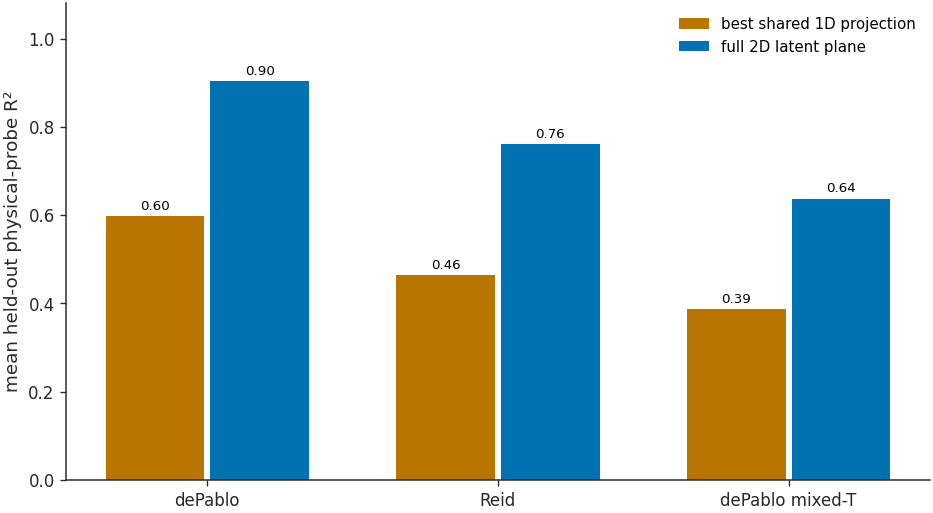

In [44]:
Z_COLUMNS = ['z0', 'z1']
PROBE_TARGETS = {
    'frame p-ratio': 'side_cumulative_p_ratio',
    'x strain': 'side_strain_x',
    'y strain': 'side_strain_y',
    'RMS displacement': 'rms_disp',
    'nonaffinity': 'nonaffine_rms',
}

def finite_probe_frame(frame):
    columns = ['sim_idx'] + Z_COLUMNS + list(PROBE_TARGETS.values())
    return frame[columns].replace([np.inf, -np.inf], np.nan).dropna()

def ridge_prediction(x_fit, y_fit, x_eval, ridge=1e-5):
    design_fit = np.column_stack([np.ones(len(x_fit)), x_fit])
    design_eval = np.column_stack([np.ones(len(x_eval)), x_eval])
    penalty = np.eye(design_fit.shape[1]); penalty[0, 0] = 0.0
    weights = np.linalg.solve(design_fit.T @ design_fit + ridge * penalty, design_fit.T @ y_fit)
    return design_eval @ weights

dimension_rows, probe_rows = [], []
for case_key, case_frame in frame_df.groupby('case', sort=False):
    case_label = case_frame.case_label.iloc[0]
    test_values = case_frame.query("split == 'test'")[Z_COLUMNS].dropna().to_numpy(float)
    centered = test_values - test_values.mean(axis=0, keepdims=True)
    covariance = centered.T @ centered / max(len(centered) - 1, 1)
    eigenvalues = np.linalg.eigvalsh(covariance)[::-1].clip(min=0)
    variance_fraction = eigenvalues / max(eigenvalues.sum(), 1e-12)
    effective_rank = float(np.exp(-(variance_fraction * np.log(variance_fraction + 1e-12)).sum()))
    participation_ratio = float(1.0 / np.square(variance_fraction).sum())
    dimension_rows.append({
        'case': case_key, 'case_label': case_label,
        'pc1_variance_fraction': variance_fraction[0], 'pc2_variance_fraction': variance_fraction[1],
        'singular_value_ratio_s2_over_s1': np.sqrt(eigenvalues[1] / max(eigenvalues[0], 1e-12)),
        'effective_rank': effective_rank, 'participation_ratio': participation_ratio, 'n_frames': len(test_values),
    })

    validation_all = finite_probe_frame(case_frame[case_frame.split.eq('val')])
    test = finite_probe_frame(case_frame[case_frame.split.eq('test')])
    validation_networks = np.sort(validation_all.sim_idx.unique())
    selection_start = max(1, len(validation_networks) // 2)
    fit_ids, selection_ids = validation_networks[:selection_start], validation_networks[selection_start:]
    train = validation_all[validation_all.sim_idx.isin(fit_ids)]
    val = validation_all[validation_all.sim_idx.isin(selection_ids)]
    x_train = train[Z_COLUMNS].to_numpy(float); y_train = train[list(PROBE_TARGETS.values())].to_numpy(float)
    x_val = val[Z_COLUMNS].to_numpy(float); y_val = val[list(PROBE_TARGETS.values())].to_numpy(float)
    x_test = test[Z_COLUMNS].to_numpy(float); y_test = test[list(PROBE_TARGETS.values())].to_numpy(float)
    x_mean, x_std = x_train.mean(0), x_train.std(0).clip(min=1e-12)
    y_mean, y_std = y_train.mean(0), y_train.std(0).clip(min=1e-12)
    x_train_z, x_val_z, x_test_z = [(values - x_mean) / x_std for values in [x_train, x_val, x_test]]
    y_train_z, y_val_z, y_test_z = [(values - y_mean) / y_std for values in [y_train, y_val, y_test]]

    candidates = np.linspace(0, np.pi, 181, endpoint=False)
    validation_scores = []
    for angle in candidates:
        direction = np.array([np.cos(angle), np.sin(angle)])
        prediction = ridge_prediction(x_train_z @ direction[:, None], y_train_z, x_val_z @ direction[:, None])
        validation_scores.append(np.nanmean([r2_score(y_val_z[:, j], prediction[:, j]) for j in range(y_val_z.shape[1])]))
    best_angle = float(candidates[int(np.nanargmax(validation_scores))])
    best_direction = np.array([np.cos(best_angle), np.sin(best_angle)])
    x_fit_z = np.row_stack([x_train_z, x_val_z]); y_fit_z = np.row_stack([y_train_z, y_val_z])
    predictions = {
        'best shared 1D projection': ridge_prediction(x_fit_z @ best_direction[:, None], y_fit_z, x_test_z @ best_direction[:, None]),
        'full 2D latent plane': ridge_prediction(x_fit_z, y_fit_z, x_test_z),
    }
    for representation, prediction in predictions.items():
        target_scores = []
        for target_index, target_label in enumerate(PROBE_TARGETS):
            score = r2_score(y_test_z[:, target_index], prediction[:, target_index])
            target_scores.append(score)
            probe_rows.append({'case': case_key, 'case_label': case_label, 'representation': representation, 'target': target_label, 'test_r2': score, 'selected_angle_degrees': np.degrees(best_angle)})
        probe_rows.append({'case': case_key, 'case_label': case_label, 'representation': representation, 'target': 'mean across targets', 'test_r2': float(np.nanmean(target_scores)), 'selected_angle_degrees': np.degrees(best_angle)})

dimension_summary = pd.DataFrame(dimension_rows)
probe_summary = pd.DataFrame(probe_rows)
dimension_summary.to_csv(OUTPUT_DIR/'latent_effective_dimension.csv', index=False)
probe_summary.to_csv(OUTPUT_DIR/'held_out_latent_dimension_probes.csv', index=False)
display(dimension_summary.round(3)); display(probe_summary.round(3))

case_order = list(CASES)
x = np.arange(len(case_order))
print('Held-out latent-plane spectrum and effective dimensionality.')
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.2), constrained_layout=True)
ordered_dimension = dimension_summary.set_index('case').reindex(case_order)
axes[0].bar(x, ordered_dimension.pc1_variance_fraction, color=PAPER_COLORS['blue'], label='PC1')
axes[0].bar(x, ordered_dimension.pc2_variance_fraction, bottom=ordered_dimension.pc1_variance_fraction, color=PAPER_COLORS['orange'], label='PC2')
axes[0].set(xticks=x, xticklabels=[DATASET_STYLE[key]['short'] for key in case_order], ylabel='variance fraction', ylim=(0, 1.05))
axes[0].legend(frameon=False)
width = .34
axes[1].bar(x-width/2, ordered_dimension.effective_rank, width, color=PAPER_COLORS['green'], label='effective rank')
axes[1].bar(x+width/2, ordered_dimension.participation_ratio, width, color=PAPER_COLORS['purple'], label='participation ratio')
axes[1].set(xticks=x, xticklabels=[DATASET_STYLE[key]['short'] for key in case_order], ylabel='effective dimensions', ylim=(1, 2.08))
axes[1].legend(frameon=False)
for ax in axes: ax.grid(False, which='both')
fig.savefig(OUTPUT_DIR/'latent_effective_dimension.png', dpi=300, bbox_inches='tight')
fig.savefig(OUTPUT_DIR/'latent_effective_dimension.pdf', bbox_inches='tight')
plt.show()

print('Held-out multivariate physical probe: best shared 1D projection versus the full 2D latent plane.')
fig, ax = plt.subplots(figsize=(7.8, 4.3), constrained_layout=True)
mean_probe = probe_summary[probe_summary.target.eq('mean across targets')]
for offset, (representation, color) in zip([-.18, .18], [('best shared 1D projection', PAPER_COLORS['orange']), ('full 2D latent plane', PAPER_COLORS['blue'])]):
    values = mean_probe[mean_probe.representation.eq(representation)].set_index('case').reindex(case_order).test_r2.clip(lower=0)
    bars = ax.bar(x + offset, values, .34, color=color, label=representation)
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=8)
ax.set(xticks=x, xticklabels=[DATASET_STYLE[key]['short'] for key in case_order], ylabel='mean held-out physical-probe R²', ylim=(0, 1.08))
ax.grid(False, which='both'); ax.legend(frameon=False)
fig.savefig(OUTPUT_DIR/'held_out_1d_vs_2d_probe.png', dpi=300, bbox_inches='tight')
fig.savefig(OUTPUT_DIR/'held_out_1d_vs_2d_probe.pdf', bbox_inches='tight')
plt.show()

Decoded response to ±1 latent standard deviation along each principal direction at frame 100.


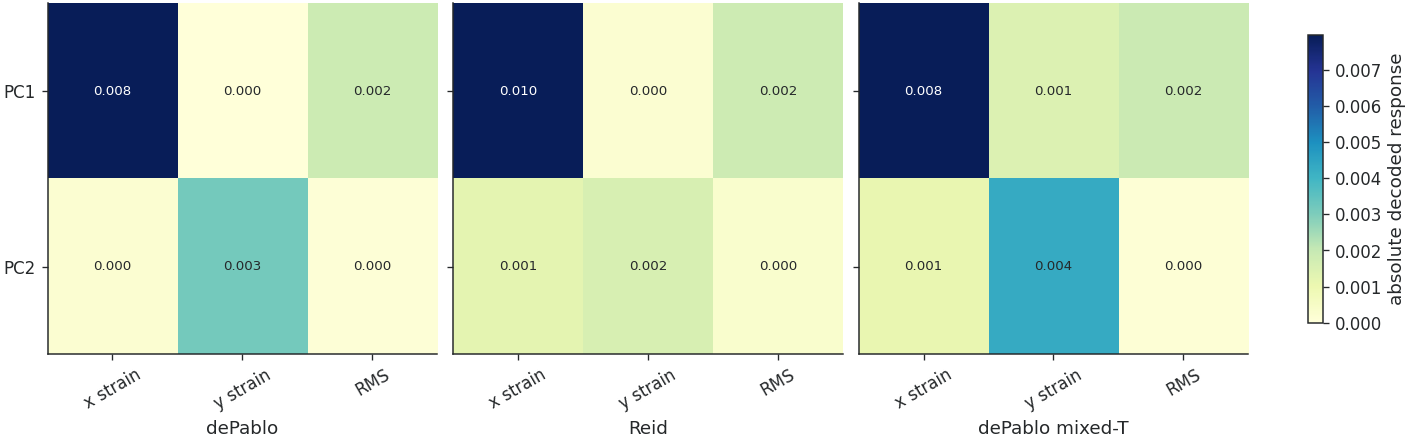

,case,case_label,absolute_response_cosine,n_networks
0,depablo_low_temp,dePablo,0.069,12
1,reid,Reid,0.605,12
2,depablo_mixed_temp,dePablo mixed-T,0.079,12


,case,case_label,direction,metric,mean_signed_response_per_latent_sd,absolute_response,n_networks
0,depablo_low_temp,dePablo,PC1,x strain,0.0079,0.0079,12
1,depablo_low_temp,dePablo,PC1,y strain,0.0000,0.0000,12
2,depablo_low_temp,dePablo,PC1,normalized RMS displacement,-0.0018,0.0018,12
3,depablo_low_temp,dePablo,PC2,x strain,-0.0002,0.0002,12
4,depablo_low_temp,dePablo,PC2,y strain,-0.0031,0.0031,12
5,depablo_low_temp,dePablo,PC2,normalized RMS displacement,0.0001,0.0001,12
6,reid,Reid,PC1,x strain,-0.0096,0.0096,12
7,reid,Reid,PC1,y strain,-0.0002,0.0002,12
8,reid,Reid,PC1,normalized RMS displacement,0.0022,0.0022,12
9,reid,Reid,PC2,x strain,-0.0015,0.0015,12


In [45]:
available_test_frames = np.sort(frame_df.loc[frame_df.split.eq('test'), 'frame_idx'].unique())
INTERVENTION_FRAME = int(available_test_frames[np.argmin(np.abs(available_test_frames - 100))])
INTERVENTION_NETWORKS = 12
INTERVENTION_METRICS = ['x strain', 'y strain', 'normalized RMS displacement']

def decoded_deformation(graph, sim):
    reference = sim[0].x[:, :2].detach().cpu().numpy()
    position = graph.x[:, :2].detach().cpu().numpy()
    side = directional_side_indices_from_box(sim[0], quantile=.10)
    width0 = reference[side['right'], 0].mean() - reference[side['left'], 0].mean()
    height0 = reference[side['top'], 1].mean() - reference[side['bottom'], 1].mean()
    width = position[side['right'], 0].mean() - position[side['left'], 0].mean()
    height = position[side['top'], 1].mean() - position[side['bottom'], 1].mean()
    scale = max(np.linalg.norm(reference.max(0) - reference.min(0)), 1e-12)
    return np.array([(width-width0)/max(abs(width0), 1e-12), (height-height0)/max(abs(height0), 1e-12), np.sqrt(np.mean(np.square(position-reference).sum(1)))/scale])

intervention_rows, intervention_geometry_rows = [], []
for case_key, result in results.items():
    validation_z = frame_df.query("case == @case_key and split == 'val'")[Z_COLUMNS].dropna().to_numpy(float)
    centered = validation_z - validation_z.mean(0, keepdims=True)
    covariance = centered.T @ centered / max(len(centered)-1, 1)
    eigenvalues, directions = np.linalg.eigh(covariance)
    order = np.argsort(eigenvalues)[::-1]; eigenvalues, directions = eigenvalues[order], directions[:, order]
    samples = frame_df.query("case == @case_key and split == 'test' and frame_idx == @INTERVENTION_FRAME").head(INTERVENTION_NETWORKS)
    signed_direction_responses = []
    for direction_index in range(2):
        perturbation = directions[:, direction_index] * np.sqrt(max(eigenvalues[direction_index], 1e-12))
        responses = []
        for _, sample in samples.iterrows():
            sim = result['test_data'][int(sample.sim_idx)]
            base_z = sample[Z_COLUMNS].to_numpy(float)
            decoded = []
            for sign in [-1.0, 1.0]:
                latent = torch.as_tensor(base_z + sign*perturbation, dtype=torch.float32, device=DEVICE)
                graph = decode_latent_to_graph(result['ae'], sim, latent, INTERVENTION_FRAME, pos_dim=2, ae_target_mode=result['params']['ae_target_mode'], normalizers=result['normalizers'], device=DEVICE)
                decoded.append(decoded_deformation(graph, sim))
            responses.append((decoded[1] - decoded[0]) / 2.0)
        mean_response = np.mean(responses, axis=0)
        signed_direction_responses.append(mean_response)
        for metric, value in zip(INTERVENTION_METRICS, mean_response):
            intervention_rows.append({'case': case_key, 'case_label': result['case_label'], 'direction': f'PC{direction_index+1}', 'metric': metric, 'mean_signed_response_per_latent_sd': value, 'absolute_response': abs(value), 'n_networks': len(samples)})
    response_a, response_b = signed_direction_responses
    cosine = abs(float(np.dot(response_a, response_b) / max(np.linalg.norm(response_a)*np.linalg.norm(response_b), 1e-12)))
    intervention_geometry_rows.append({'case': case_key, 'case_label': result['case_label'], 'absolute_response_cosine': cosine, 'n_networks': len(samples)})

intervention_summary = pd.DataFrame(intervention_rows)
intervention_geometry = pd.DataFrame(intervention_geometry_rows)
intervention_summary.to_csv(OUTPUT_DIR/'latent_direction_interventions.csv', index=False)
intervention_geometry.to_csv(OUTPUT_DIR/'latent_direction_response_geometry.csv', index=False)
print(f'Decoded response to ±1 latent standard deviation along each principal direction at frame {INTERVENTION_FRAME}.')
fig, axes = plt.subplots(1, len(CASES), figsize=(11.8, 3.7), sharey=True, constrained_layout=True)
for ax, case_key in zip(axes, CASES):
    table = intervention_summary[intervention_summary.case.eq(case_key)].pivot(index='direction', columns='metric', values='absolute_response').reindex(['PC1','PC2'])[INTERVENTION_METRICS]
    image = ax.imshow(table, cmap='YlGnBu', vmin=0, aspect='auto')
    ax.set(xlabel=DATASET_STYLE[case_key]['short'], xticks=range(len(INTERVENTION_METRICS)), xticklabels=['x strain','y strain','RMS'], yticks=[0,1], yticklabels=['PC1','PC2'])
    ax.tick_params(axis='x', rotation=30); ax.grid(False, which='both')
    for row_index in range(2):
        for column_index in range(3):
            value = table.iloc[row_index, column_index]
            ax.text(column_index, row_index, f'{value:.3f}', ha='center', va='center', fontsize=8, color='white' if value > .65*max(table.to_numpy().max(), 1e-12) else PAPER_COLORS['ink'])
fig.colorbar(image, ax=axes, label='absolute decoded response', shrink=.82)
fig.savefig(OUTPUT_DIR/'latent_direction_interventions.png', dpi=300, bbox_inches='tight')
fig.savefig(OUTPUT_DIR/'latent_direction_interventions.pdf', bbox_inches='tight')
plt.show()
display(intervention_geometry.round(3)); display(intervention_summary.round(4))

## Figure 3 — A stable shared coordinate system

The rotation is learned from training trajectories only. The same frozen coordinates are then used for held-out trajectories and coordinate-swap decoding.

Figure 3: training-defined latent coordinates, held-out trajectories, and response-coordinate swaps.


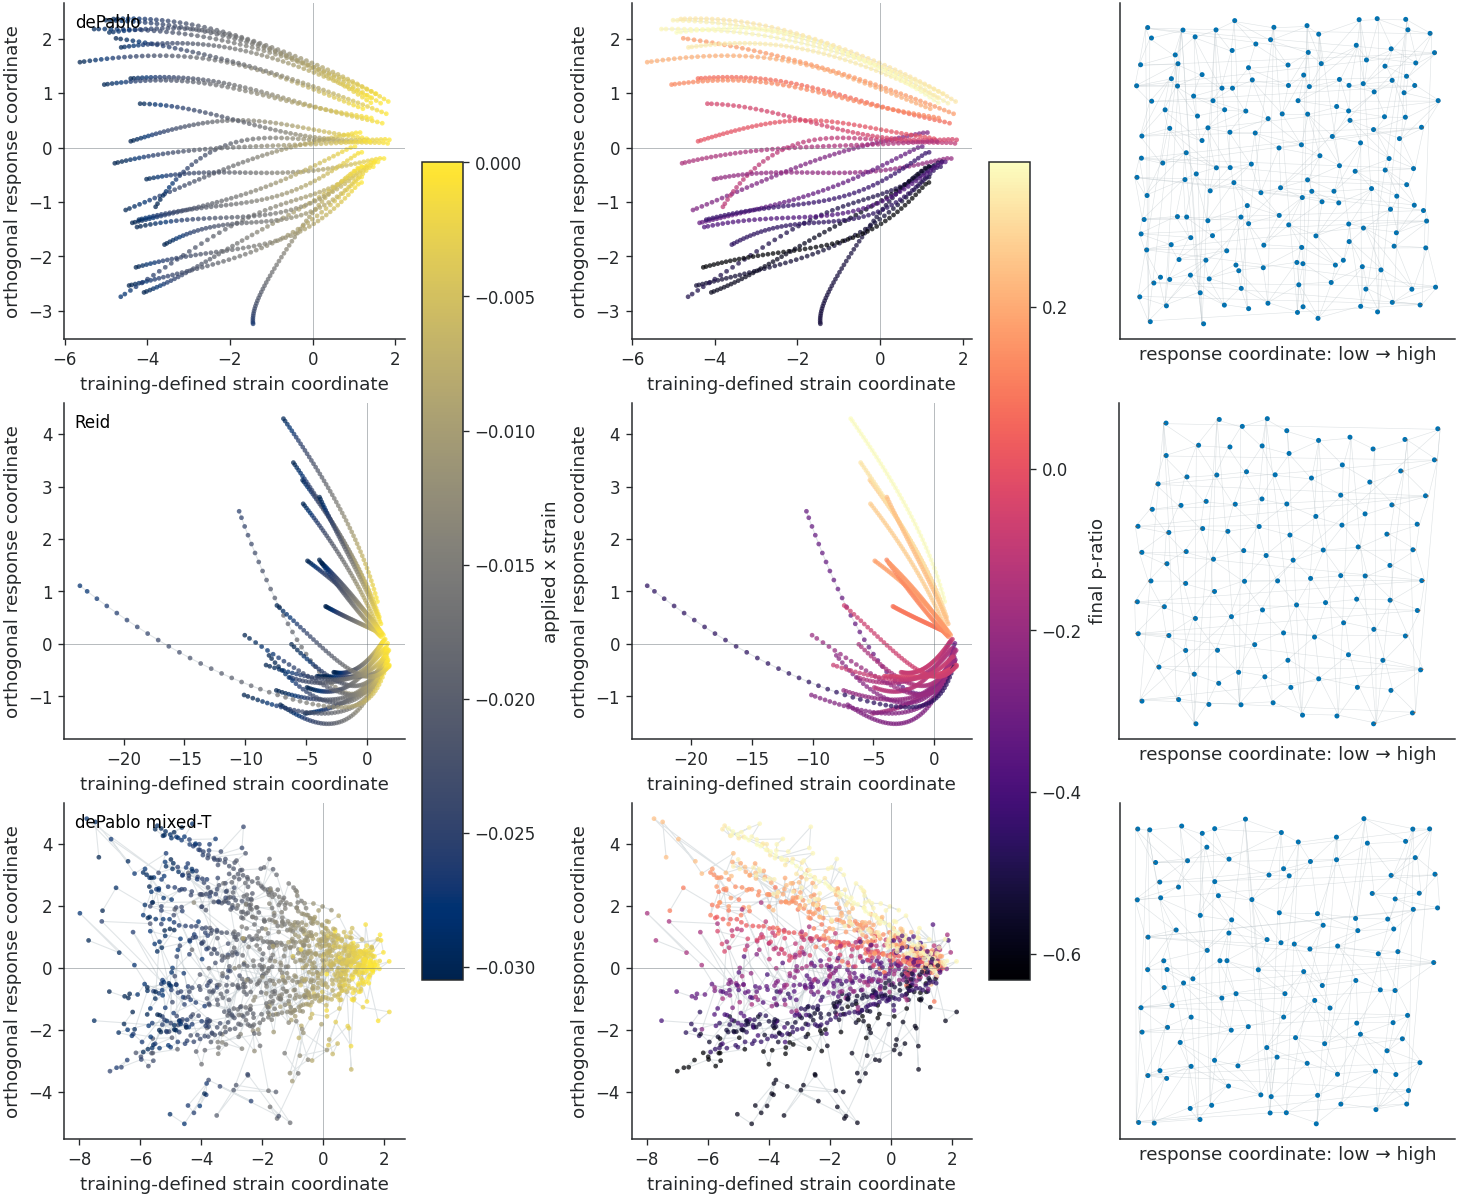

,case,axis,z0_standardized_weight,z1_standardized_weight,training_rows
0,depablo_low_temp,q_strain,-0.241,0.971,280
1,depablo_low_temp,q_response,0.971,0.241,280
2,reid,q_strain,0.702,-0.712,420
3,reid,q_response,-0.712,-0.702,420
4,depablo_mixed_temp,q_strain,0.732,-0.682,280
5,depablo_mixed_temp,q_response,-0.682,-0.732,280


,case,reference_sim_idx,donor_sim_idx,reference_p_ratio,donor_p_ratio,swapped_q_strain,swapped_q_response,decoded_x_strain,decoded_y_strain,decoded_normalized_rms
0,depablo_low_temp,94,153,-0.633,0.406,-1.417,1.972,-0.013,0.005,0.003
1,reid,36,7,-0.466,0.379,-4.453,2.705,-0.019,0.006,0.005
2,depablo_mixed_temp,12,222,-0.800,0.405,-2.717,2.189,-0.015,0.003,0.003


In [46]:
FIGURE3_TRAIN_STRIDE = 8
FIGURE3_MAX_HELDOUT_TRAJECTORIES = 24
FIGURE3_FRAME = INTERVENTION_FRAME

def fit_training_coordinate_system(result):
    rows = []
    with torch.no_grad():
        for sim_index, sim in enumerate(result['train_data']):
            side = directional_side_indices_from_box(sim[0], quantile=.10)
            reference = sim[0].x[:, :2].detach().cpu().numpy()
            width0 = reference[side['right'], 0].mean() - reference[side['left'], 0].mean()
            final_p_ratio = float(calc_p_ratio_rollout_sides(sim, -1, side_idx=side))
            frames = list(range(0, min(FIGURE3_FRAME, len(sim)-1)+1, FIGURE3_TRAIN_STRIDE))
            if FIGURE3_FRAME < len(sim) and FIGURE3_FRAME not in frames: frames.append(FIGURE3_FRAME)
            for frame in frames:
                position = sim[frame].x[:, :2].detach().cpu().numpy()
                width = position[side['right'], 0].mean() - position[side['left'], 0].mean()
                z = encode_frame_latent(result['ae'], sim, frame, pos_dim=2, node_feature_mode=result['params']['node_feature_mode'], normalizers=result['normalizers'], device=DEVICE).detach().cpu().numpy()
                rows.append({'sim_idx': sim_index, 'frame_idx': frame, 'z0': z[0], 'z1': z[1], 'x_strain': (width-width0)/max(abs(width0), 1e-12), 'final_p_ratio': final_p_ratio})
    training = pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan).dropna()
    z = training[Z_COLUMNS].to_numpy(float)
    mean = z.mean(0); std = z.std(0).clip(min=1e-12); standardized = (z-mean)/std
    strain = training.x_strain.to_numpy(float); strain = (strain-strain.mean())/max(strain.std(), 1e-12)
    direction_1 = np.linalg.solve(standardized.T@standardized + 1e-5*np.eye(2), standardized.T@strain)
    direction_1 = direction_1/max(np.linalg.norm(direction_1), 1e-12)
    if np.corrcoef(standardized@direction_1, strain)[0,1] < 0: direction_1 *= -1
    direction_2 = np.array([-direction_1[1], direction_1[0]])
    if np.corrcoef(standardized@direction_2, training.final_p_ratio)[0,1] < 0: direction_2 *= -1
    rotation = np.column_stack([direction_1, direction_2])
    return {'mean': mean, 'std': std, 'rotation': rotation, 'training_rows': len(training)}

coordinate_systems = {key: fit_training_coordinate_system(result) for key, result in results.items()}
coordinate_rows, figure3_parts = [], []
for case_key, system in coordinate_systems.items():
    for axis_index, axis_label in enumerate(['q_strain', 'q_response']):
        coordinate_rows.append({'case': case_key, 'axis': axis_label, 'z0_standardized_weight': system['rotation'][0,axis_index], 'z1_standardized_weight': system['rotation'][1,axis_index], 'training_rows': system['training_rows']})
    heldout = frame_df.query("case == @case_key and split == 'test'").copy()
    q = ((heldout[Z_COLUMNS].to_numpy(float)-system['mean'])/system['std']) @ system['rotation']
    heldout['q_strain'], heldout['q_response'] = q[:,0], q[:,1]
    figure3_parts.append(heldout)
figure3_frame = pd.concat(figure3_parts, ignore_index=True)
training_coordinate_axes = pd.DataFrame(coordinate_rows)
training_coordinate_axes.to_csv(OUTPUT_DIR/'figure3_training_defined_axes.csv', index=False)
figure3_frame.to_csv(OUTPUT_DIR/'figure3_heldout_rotated_latents.csv', index=False)

strain_norm = Normalize(vmin=figure3_frame.side_strain_x.quantile(.01), vmax=figure3_frame.side_strain_x.quantile(.99))
pratio_norm = Normalize(vmin=figure3_frame.side_final_trajectory_p_ratio.quantile(.01), vmax=figure3_frame.side_final_trajectory_p_ratio.quantile(.99))
strain_cmap, pratio_cmap = plt.get_cmap('cividis'), plt.get_cmap('magma')
swap_rows = []
print('Figure 3: training-defined latent coordinates, held-out trajectories, and response-coordinate swaps.')
fig, axes = plt.subplots(len(CASES), 3, figsize=(12.2, 10.0), constrained_layout=True)
for row_index, case_key in enumerate(CASES):
    case_frame = figure3_frame[figure3_frame.case.eq(case_key)]
    network_order = case_frame.groupby('sim_idx').side_final_trajectory_p_ratio.first().sort_values()
    select_positions = np.unique(np.linspace(0, len(network_order)-1, min(FIGURE3_MAX_HELDOUT_TRAJECTORIES, len(network_order)), dtype=int))
    selected_ids = network_order.index.to_numpy()[select_positions]
    selected = case_frame[case_frame.sim_idx.isin(selected_ids)]
    for ax, color_column, cmap, norm in [(axes[row_index,0], 'side_strain_x', strain_cmap, strain_norm), (axes[row_index,1], 'side_final_trajectory_p_ratio', pratio_cmap, pratio_norm)]:
        for _, trajectory in selected.sort_values('frame_idx').groupby('sim_idx'):
            ax.plot(trajectory.q_strain, trajectory.q_response, color=PAPER_COLORS['light'], lw=.65, alpha=.42, zorder=1)
        ax.scatter(selected.q_strain, selected.q_response, c=selected[color_column], cmap=cmap, norm=norm, s=8, alpha=.72, edgecolor='none', zorder=2)
        ax.axhline(0, color=PAPER_COLORS['slate'], lw=.6, alpha=.45); ax.axvline(0, color=PAPER_COLORS['slate'], lw=.6, alpha=.45)
        ax.set(xlabel='training-defined strain coordinate', ylabel='orthogonal response coordinate')
        ax.grid(False, which='both')
    axes[row_index,0].text(.03,.97,DATASET_STYLE[case_key]['short'],transform=axes[row_index,0].transAxes,ha='left',va='top')

    low_id, high_id = int(network_order.index[0]), int(network_order.index[-1])
    low_row = case_frame.query('sim_idx == @low_id and frame_idx == @FIGURE3_FRAME').iloc[0]
    high_row = case_frame.query('sim_idx == @high_id and frame_idx == @FIGURE3_FRAME').iloc[0]
    system = coordinate_systems[case_key]
    q_low = low_row[['q_strain','q_response']].to_numpy(float); q_high = high_row[['q_strain','q_response']].to_numpy(float)
    q_swap = np.array([q_low[0], q_high[1]])
    z_swap = (q_swap @ system['rotation'].T)*system['std'] + system['mean']
    sim = results[case_key]['test_data'][low_id]
    swap_graph = decode_latent_to_graph(results[case_key]['ae'], sim, torch.as_tensor(z_swap, dtype=torch.float32, device=DEVICE), FIGURE3_FRAME, pos_dim=2, ae_target_mode=results[case_key]['params']['ae_target_mode'], normalizers=results[case_key]['normalizers'], device=DEVICE)
    reference = sim[0].x[:,:2].detach().cpu().numpy(); swapped = swap_graph.x[:,:2].detach().cpu().numpy(); delta = swapped-reference
    edge_index = sim[0].edge_index.detach().cpu().numpy().T
    if getattr(sim[0], 'edge_attr', None) is not None: edge_index = edge_index[sim[0].edge_attr[:,-1].detach().cpu().numpy() > 0]
    ax = axes[row_index,2]
    for u,v in edge_index: ax.plot(reference[[u,v],0], reference[[u,v],1], color=PAPER_COLORS['light'], lw=.35, alpha=.45, zorder=1)
    ax.scatter(swapped[:,0], swapped[:,1], color=PAPER_COLORS['blue'], s=9, edgecolor='none', zorder=2)
    ax.quiver(reference[:,0], reference[:,1], delta[:,0], delta[:,1], angles='xy', scale_units='xy', scale=1, color=PAPER_COLORS['red'], alpha=.62, width=.003, zorder=3)
    ax.set(xlabel='response coordinate: low → high', ylabel=''); ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False, which='both')
    deformation = decoded_deformation(swap_graph, sim)
    swap_rows.append({'case': case_key, 'reference_sim_idx': low_id, 'donor_sim_idx': high_id, 'reference_p_ratio': low_row.side_final_trajectory_p_ratio, 'donor_p_ratio': high_row.side_final_trajectory_p_ratio, 'swapped_q_strain': q_swap[0], 'swapped_q_response': q_swap[1], 'decoded_x_strain': deformation[0], 'decoded_y_strain': deformation[1], 'decoded_normalized_rms': deformation[2]})

fig.colorbar(plt.cm.ScalarMappable(norm=strain_norm, cmap=strain_cmap), ax=axes[:,0], label='applied x strain', shrink=.72)
fig.colorbar(plt.cm.ScalarMappable(norm=pratio_norm, cmap=pratio_cmap), ax=axes[:,1], label='final p-ratio', shrink=.72)
fig.savefig(OUTPUT_DIR/'figure3_stable_shared_coordinate_system.png', dpi=300, bbox_inches='tight')
fig.savefig(OUTPUT_DIR/'figure3_stable_shared_coordinate_system.pdf', bbox_inches='tight')
plt.show()
coordinate_swap_reconstructions = pd.DataFrame(swap_rows)
coordinate_swap_reconstructions.to_csv(OUTPUT_DIR/'figure3_coordinate_swap_reconstructions.csv', index=False)
display(training_coordinate_axes.round(3)); display(coordinate_swap_reconstructions.round(3))

## Latent Rollout

,case_label,split,rollout_steps,p_ratio_r2,p_ratio_pearson
12,dePablo,train,10,0.8836,0.9625
13,dePablo,train,20,0.9489,0.9774
14,dePablo,train,50,0.9754,0.9918
15,dePablo,train,100,0.9895,0.9948
16,dePablo,train,150,0.9819,0.9952
...,...,...,...,...,...
265,dePablo mixed-T,test,20,-0.2431,0.3483
266,dePablo mixed-T,test,50,0.5940,0.7855
267,dePablo mixed-T,test,100,0.8329,0.9294
268,dePablo mixed-T,test,150,0.6649,0.8883


Plot: latent rollout quality versus rollout horizon


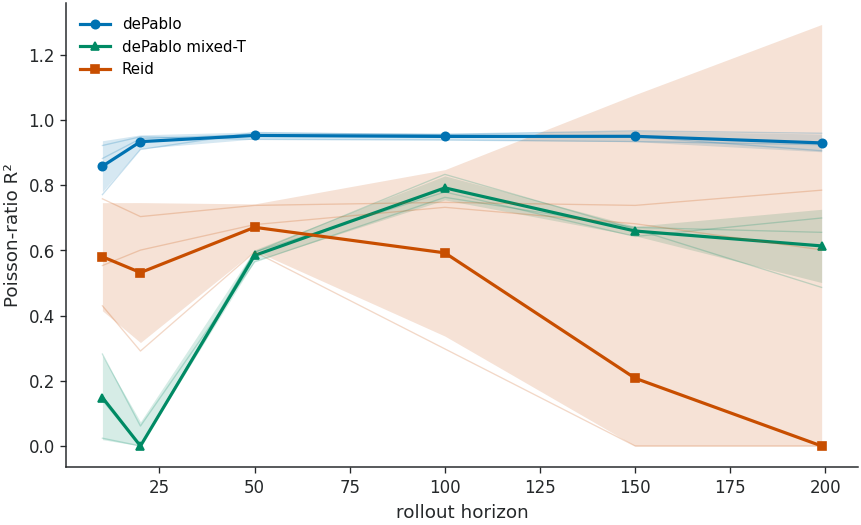

In [47]:
display_cols = ["case_label", "split", "rollout_steps", "p_ratio_r2", "p_ratio_pearson"]
display(rollout_stats_df[display_cols + ['repeat_index', 'model_seed']].round(4))
display(three_seed_rollout_summary.query("split == 'test'").round(4))

print("Plot: latent rollout quality versus rollout horizon")
fig, ax = plt.subplots(figsize=(7.2, 4.4), constrained_layout=True)
test_stats = rollout_stats_df[rollout_stats_df["split"].eq("test")].copy()
for case_key, group in test_stats.groupby("case"):
    style = DATASET_STYLE.get(case_key, {"color": None, "marker": "o", "short": case_key})
    for _, seed_group in group.groupby('repeat_index'):
        seed_group = seed_group.sort_values('rollout_steps')
        ax.plot(seed_group.rollout_steps, seed_group.p_ratio_r2.clip(lower=0), color=style['color'], lw=.8, alpha=.22)
    summary = group.groupby('rollout_steps').p_ratio_r2.agg(['mean','std']).reset_index().sort_values('rollout_steps')
    mean = summary['mean'].clip(lower=0); lower = (summary['mean']-summary['std']).clip(lower=0); upper = (summary['mean']+summary['std']).clip(lower=0)
    ax.fill_between(summary.rollout_steps, lower, upper, color=style['color'], alpha=.16, linewidth=0)
    ax.plot(summary.rollout_steps, mean, marker=style['marker'], color=style['color'], lw=1.9, label=style['short'])
style_axes(ax, xlabel="rollout horizon", ylabel="Poisson-ratio R²", legend=True)
plt.show()
fig.savefig(OUTPUT_DIR / "latent_rollout_quality.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "latent_rollout_quality.pdf", bbox_inches="tight")


## Notes For The Paper Narrative

- Inspect whether `z0` and `z1` have different correlation signatures rather than treating the 2D latent as two interchangeable axes.
- The readout table asks whether initial latent position, latent trajectory slope, or both carry Poisson-ratio information.
- The rollout section separates representation quality from dynamical prediction quality.